# Wrangling and Summarizing Data

Read this notebook from top to bottom and fill in the code as you go. Work together and discuss with other students in the class. Try to resolve any errors on your own first, but don't get stuck; ask for help!

In addition to writing and running code, be sure to examine any output and interpret the results before moving on.

For many of these questions, there are several ways to do it in Pandas. You only need to choose one that works. But you might want to experiment with multiple ways of doing the same thing to get practice working with Pandas. However, you should generally try to find the simplest solution. In particular, use `groupby` whenever possible to streamline the code.

In [115]:
import pandas as pd

## Titanic data

In [116]:
df_titanic = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/main/data/titanic.csv")
df_titanic

,name,gender,age,class,embarked,country,ticketno,fare,survived,pclass,crew
0,"Abbing, Mr. Anthony",male,42.0,3rd,S,United States,5547.0,7.11,0,3.0,NaN
1,"Abbott, Mr. Eugene Joseph",male,13.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
2,"Abbott, Mr. Rossmore Edward",male,16.0,3rd,S,United States,2673.0,20.05,0,3.0,NaN
3,"Abbott, Mrs. Rhoda Mary 'Rosa'",female,39.0,3rd,S,England,2673.0,20.05,1,3.0,NaN
4,"Abelseth, Miss. Karen Marie",female,16.0,3rd,S,Norway,348125.0,7.13,1,3.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2202,"Wynn, Mr. Walter",male,41.0,deck crew,B,England,NaN,NaN,1,NaN,deck crew
2203,"Yearsley, Mr. Harry",male,40.0,victualling crew,S,England,NaN,NaN,1,NaN,victualling crew
2204,"Young, Mr. Francis James",male,32.0,engineering crew,S,England,NaN,NaN,0,NaN,engineering crew
2205,"Zanetti, Sig. Minio",male,20.0,restaurant staff,S,England,NaN,NaN,0,NaN,restaurant staff


1\. Create a new variable "type" that takes values either "passenger" or "crew".

In [117]:
def re_class_for_type_var(c):
    if c in['1st', '2nd', '3rd']:
        return 'passenger'
    else:
        return 'crew'

df_titanic["type"]= df_titanic["class"].map(re_class_for_type_var)

In [118]:
pd.crosstab(df_titanic["class"], df_titanic["type"])


type,crew,passenger
class,,
1st,0,324
2nd,0,284
3rd,0,709
deck crew,66,0
engineering crew,324,0
restaurant staff,69,0
victualling crew,431,0


2\. Find the proportion those onboard who were passengers and the proportion who were crew. Do this by creating a Series with these proportions.

In [119]:
df_titanic["type"].value_counts(normalize=True)

type
passenger    0.596738
crew         0.403262
Name: proportion, dtype: float64

3\. Note that "survived" is a categorical variable that has been one-hot encoded as a dummy (aka Bernoulli aka indicator) numerical variable with 1 = survived and 0 = not survived. (Check its dtype.) Find the proportion of those onboard who survived. You could do this with `value_counts` like for "type", but try a different way that takes advantage of the fact that "survived" is a numerical type. (Hint: what happens if you sum the values of a 1/0 variable? What happens if you take the mean of the values of a 1/0 variable?)

In [120]:
df_titanic["survived"].dtype

dtype('int64')

In [121]:
df_titanic["survived"].mean()
df_titanic["survived"].value_counts(normalize=True)

survived
0    0.677843
1    0.322157
Name: proportion, dtype: float64

4\. Create a crosstab (two-way table) summarizing the joint distribution of "survived" and "type". (Notice that we can treat the dummy variable "survived" as both a categorical variable and a numerical variable, whichever is convenient.)

In [122]:
pd.crosstab(df_titanic["survived"], df_titanic["type"])
pd.crosstab(df_titanic["survived"], df_titanic["type"], normalize = True)

type,crew,passenger
survived,,
0,0.307657,0.370186
1,0.095605,0.226552


5\. Compare the proportion of passengers who survived and the proportion of crew members who survived. Do this by creating a Series that contains these two proportions. Who was more likely to survive: passengers or crew?

Hint: there are a few ways of doing this, several of which avoid explicitly dividing. Can you take advantage of `groupby` and the fact that "survived" is a dummy variable?

In [123]:
df_titanic.groupby("type")["survived"].mean()


type
crew         0.237079
passenger    0.379651
Name: survived, dtype: float64

In [124]:

pd.crosstab(df_titanic["type"], df_titanic["survived"], normalize="index")

survived,0,1
type,,
crew,0.762921,0.237079
passenger,0.620349,0.379651


6\. The "gender" variable is coded only as "male" or "female". Among males only, compare the proportion of passengers who survived and the proportion of cew who survived. Among males, who was more likely to survive: passengers or crew? Then do the same thing among females only. Among females, who was more likely to survive: passengers or crew?

Do this by creating a Series that contains the 4 proportions you need. Hint: if you used `groupby` in the previous part you should only need a small change here.

In [125]:
print(df_titanic.groupby(["gender", "type"])["survived"].mean())

gender  type     
female  crew         0.869565
        passenger    0.727468
male    crew         0.220300
        passenger    0.189189
Name: survived, dtype: float64


7\. Compare your answers to 5 and 6. What do you notice? Can you explain why this happens? Suggest an explanation and then create summaries of the data to support your explanation.

In [126]:
# YOUR CODE HERE.
df_titanic.groupby(["gender"])["survived"].mean()

gender
female    0.734151
male      0.204889
Name: survived, dtype: float64

In [127]:
print(df_titanic.groupby(["gender"])["type"].value_counts(normalize = True))

gender  type     
female  passenger    0.952965
        crew         0.047035
male    crew         0.504657
        passenger    0.495343
Name: proportion, dtype: float64


## College Scorecard

The [College Scorecard](https://collegescorecard.ed.gov/) was an effort started by the U.S. Department of Education to help students make more informed choices about colleges. Data from 2022 is available at https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv


In [128]:
df_college = pd.read_csv("https://raw.githubusercontent.com/kevindavisross/data301/refs/heads/main/data/college_scorecard_2022.csv")

df_college

,Institution,City,State,Undergraduates,Median Earnings
0,Alabama A & M University,Normal,AL,5098.0,39059.0
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0
2,Amridge University,Montgomery,AL,251.0,37730.0
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0
4,Alabama State University,Montgomery,AL,3495.0,34018.0
...,...,...,...,...,...
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0
6541,Pennsylvania State University-Penn State Brand...,Media,PA,NaN,61185.0


1\. What is the observational unit? Make a guess for how the earnings variable is computed.

Each institution.

2\. Write code to find the California Polytechnic row in the data set!

In [129]:
df_college[df_college["Institution"].str.contains("California Polytechnic")]

,Institution,City,State,Undergraduates,Median Earnings
194,California Polytechnic State University-San Lu...,San Luis Obispo,CA,21090.0,85801.0


3\. The data set contains information about the median earnings of students who attended each college, 10 years after they first enrolled. The earnings are taken directly from the W2 tax forms of all students who received federal financial aid.

Notice the earnings are missing (NaN). Create a subset data frame that only includes colleges with non-missing earnings. Use this subset to answer the remaining questions.

In [130]:
df_college_clean = df_college.dropna(subset = ["Median Earnings"])
len(df_college_clean)

5165

4\. Summarize the earnings variable, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command! What is larger: the mean or the median? Why? Then create a histogram of the earnings variable.

In [131]:
df_college_clean["Median Earnings"].describe()

count      5165.000000
mean      41128.801355
std       16185.531482
min       11085.000000
25%       29448.000000
50%       38696.000000
75%       49077.000000
max      129442.000000
Name: Median Earnings, dtype: float64

<Axes: ylabel='Frequency'>

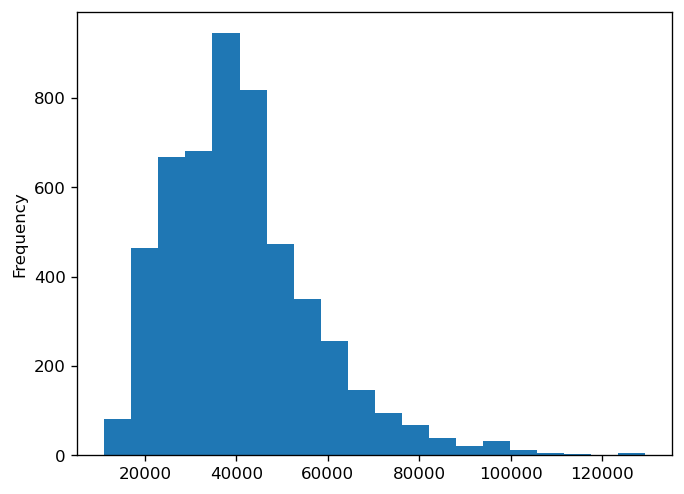

In [132]:
df_college_clean["Median Earnings"].plot.hist(bins = 20)

The mean is larger than the median. This is shown through the right-skewed histogram plot. 

5\. Create a new column with the log of earnings, then create a histogram. How does the shape of the histogram of log earnings compare to earnings itself?

In [133]:
import numpy as np

In [134]:
df_college_clean["log(Median Earnings)"] = np.log(df_college_clean["Median Earnings"])

<positron-console-cell-134>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [135]:
df_college_clean

,Institution,City,State,Undergraduates,Median Earnings,log(Median Earnings)
0,Alabama A & M University,Normal,AL,5098.0,39059.0,10.572829
1,University of Alabama at Birmingham,Birmingham,AL,13284.0,50907.0,10.837756
2,Amridge University,Montgomery,AL,251.0,37730.0,10.538211
3,University of Alabama in Huntsville,Huntsville,AL,7358.0,56901.0,10.949068
4,Alabama State University,Montgomery,AL,3495.0,34018.0,10.434645
...,...,...,...,...,...,...
6537,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,61185.0,11.021657
6538,Pennsylvania State University-Penn State York,York,PA,NaN,61185.0,11.021657
6539,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,61185.0,11.021657
6540,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,61185.0,11.021657


<Axes: ylabel='Frequency'>

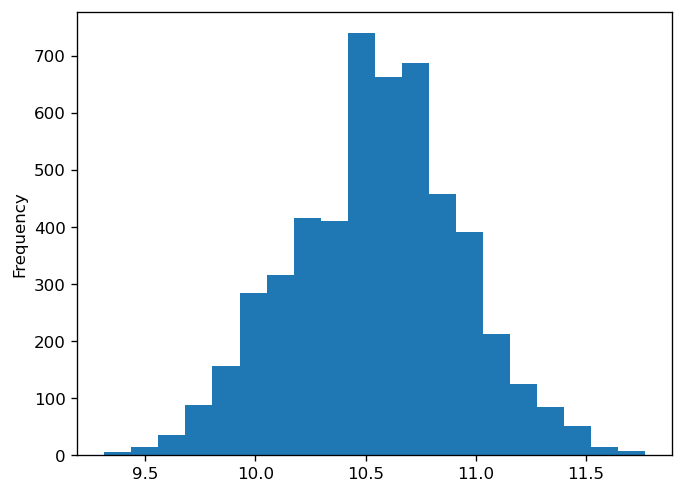

In [136]:
df_college_clean["log(Median Earnings)"].plot.hist(bins = 20)

6\. The mean gives every college equal weight. But some colleges are tiny (e.g., San Francisco Conservatory, with 228 undergraduates), while others are large (e.g., Penn State, with 72229 undergraduates!).

If we are interested in what *students* earn, we might want to give more weight to colleges with more students. To do this, we can calculate a **weighted mean**:

$$ \sum_{i=1}^n w_i x_i. $$

In general, the weights $w_1, w_2, ..., w_n$ should all be non-negative and should add up to $1.0$. (For the usual mean, every observation gets equal weight, $1/n$.)

Calculate a weighted mean of earnings, using the undergraduate enrollments as weights. Do this by first adding a "weight" column to the data set (number of undegraduates for the college divided by the total number of undergraduates in the data set).

In [149]:
df_college_clean["State Weight"] = df_college_clean["Undergraduates"] / df_college_clean["Undergraduates"].sum()


<positron-console-cell-149>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


In [150]:
weighted_mean_by_state = (
    (df_college_clean["Median Earnings"] * df_college_clean["State Weight"])
    .groupby(df_college_clean["State"])
    .sum()
    .sort_values(ascending=False)
)

weighted_mean_by_state

State
CA    7357.180021
TX    4134.744414
NY    3363.813684
FL    2736.213833
PA    2005.649780
IL    1712.223728
OH    1613.252498
AZ    1471.304290
MA    1446.553869
VA    1431.628055
GA    1391.421184
MI    1361.318291
NC    1352.041223
NJ    1204.984266
UT    1134.729160
IN    1082.103961
MD     976.678855
WA     966.923592
WI     877.237075
MN     833.487075
CO     828.931396
MO     773.357482
TN     763.384635
AL     722.103948
NH     630.271958
CT     623.032660
SC     618.815897
LA     570.430251
OR     556.888395
IA     507.497659
KY     499.384661
OK     498.157675
KS     443.394722
WV     351.265671
MS     332.411511
AR     327.829454
NE     323.468173
NV     317.002960
ID     311.922541
PR     280.411801
RI     276.151247
DC     264.545341
NM     207.432483
DE     174.010572
ME     161.527502
HI     146.144279
ND     139.074916
VT     129.803507
SD     120.539891
MT     118.784073
WY      65.143139
AK      45.620749
GU       9.900134
VI       3.772415
FM       3.265819
MH  

7\. Compute the mean of earnings for each state. Sort the states in descending order of mean earnings. Display the results in a bar chart.

<Axes: xlabel='State'>

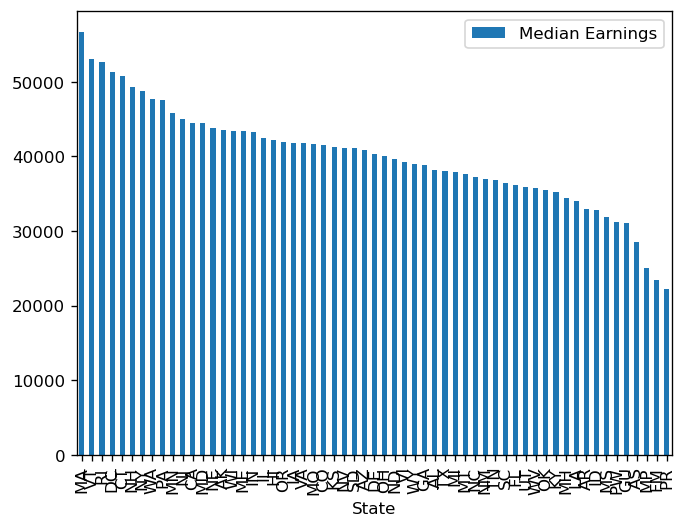

In [ ]:
df_college_clean[["Median Earnings", "State"]].groupby("State").mean().sort_values("Median Earnings", ascending= False).plot.bar()

8\. Repeat the previous part, but now compute a weighted mean of earnings for each state, using the number of undegraduate enrollments in the state as weights. (Hint: use `groupby` with `transform`.)

<positron-console-cell-82>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


<Axes: xlabel='State'>

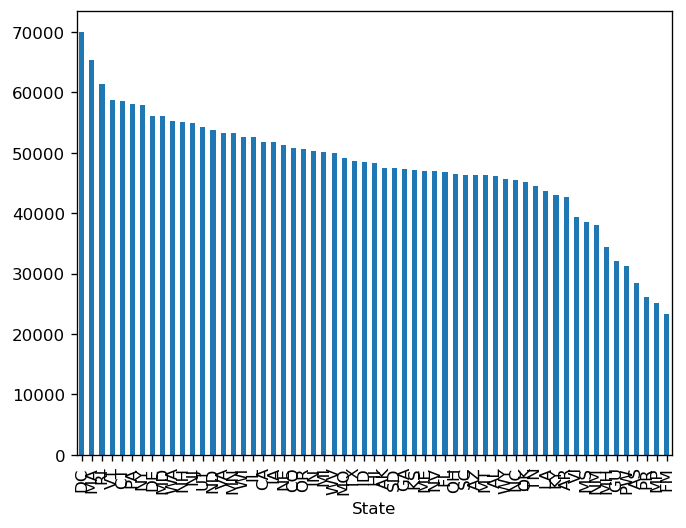

In [ ]:
df_college_clean["State Weight"] = (
    df_college_clean["Undergraduates"]
    / df_college_clean.groupby("State")["Undergraduates"].transform("sum")
)

state_weighted_mean = (
    (df_college_clean["Median Earnings"] * df_college_clean["State Weight"])
    .groupby(df_college_clean["State"])
    .sum()
    .sort_values(ascending=False)
)

state_weighted_mean.plot.bar()

## Olympic Men's Gymnastics Data



The file https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv contains scores from the qualification and final rounds of the Olympic men's gymnastics all around competition from 2008 to 2020. (Thanks to Martin Hsu for scraping this data set.)

In [ ]:
df_gym = pd.read_csv("https://raw.githubusercontent.com/mshsu/probasets/refs/heads/main/data/OlympicAllAround.csv")

df_gym

,Pos,Gymnast,NOC,Points,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse,Round,Year
0,1.0,Danell Leyva,USA,91.265,15.100,15.500,15.333,15.866,14.600,14.866,Qualification,2012
1,2.0,David Belyavsky,RUS,90.832,15.100,16.300,15.300,14.866,14.366,14.900,Qualification,2012
2,3.0,Fabian HambÃ¼chen,GER,90.765,15.133,15.833,15.300,15.633,14.766,14.100,Qualification,2012
3,4.0,John Orozco,USA,90.597,15.166,15.800,14.533,15.266,15.066,14.766,Qualification,2012
4,5.0,Kristian Thomas,GBR,90.256,15.366,16.200,14.625,15.366,14.566,14.133,Qualification,2012
...,...,...,...,...,...,...,...,...,...,...,...,...
346,20.0,Daniel Keatings,GBR,89.000,14.850,15.800,14.425,14.225,14.000,15.700,Final,2008
347,21.0,Thomas Bouhail,FRA,87.000,15.200,15.850,14.425,14.475,13.650,13.400,Final,2008
348,22.0,José Luis Fuentes,VEN,86.300,14.175,15.250,15.175,14.150,13.900,13.650,Final,2008
349,23.0,Dzmitry Savitski,BLR,82.175,13.725,15.900,13.400,10.100,15.300,13.750,Final,2008


1\. Create a data frame

- With [Round, Year, Gymnast] as the (multi) index, and
- Containing only the six columns with the event scores, "Floor Exercise" through "Pommelled Horse"

In [ ]:
df_gym_events = (
    df_gym
    .set_index(["Round", "Year", "Gymnast"])
    .loc[:, "Floor Exercise":"Pommelled Horse"]
)

(df_gym_events)

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar   Rings  Pommelled Horse
Round         Year Gymnast                                                                                               
Qualification 2012 Danell Leyva               15.100       15.500         15.333          15.866  14.600           14.866
                   David Belyavsky            15.100       16.300         15.300          14.866  14.366           14.900
                   Fabian HambÃ¼chen          15.133       15.833         15.300          15.633  14.766           14.100
                   John Orozco                15.166       15.800         14.533          15.266  15.066           14.766
                   Kristian Thomas            15.366       16.200         14.625          15.366  14.566           14.133
...                                              ...          ...            ...             ...     ...              ...
Final         2008 Daniel Keatings            14.850       15.800         14.425          14.225  14.000           15.700
                   Thomas Bouhail             15.200       15.850         14.425          14.475  13.650           13.400
                   José Luis Fuentes          14.175       15.250         15.175          14.150  13.900           13.650
                   Dzmitry Savitski           13.725       15.900         13.400          10.100  15.300           13.750
                   Chen Yibing                   NaN       15.900         14.950          12.975  16.650           13.750

[351 rows x 6 columns]

2\. Summarize the scores for each of the six events, by finding the sample size, mean, SD, and *five number summary* (minimum, 25th percentile, median, 75th percentile, maximum). Hint: you can do all this with a single command!

In [ ]:
df_gym_events.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,324.000000,318.000000,325.000000
mean,14.309133,14.976551,14.719288,14.082562,14.237799,13.816723
std,1.254009,0.959876,0.920044,1.299542,0.914523,1.242348
min,1.633000,11.766000,10.200000,0.000000,7.700000,0.000000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.854000,14.831000,14.566000
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


3\. There are 351 rows in the data frame. Why are the sample sizes different for each event, and not all equal to 351?

The sample sizes differ because some gymnasts have missing scores for certain events. Pandas excludes these missing values when calculating each event’s sample size.

4\. In the all around competition, each gymnast competes all six events, but this doesn't always happen (due to injury, etc). Therefore, there are some missing values in the data. Most of the missing values are coded as `NaN` but some are coded as 0. What would be a more appropriate way to code the missing values in this case: `NaN` or 0? Why?

NaN because 0 is a real score that someone can receive.

5\. Replace all scores of 0 in the data frame with `NaN`. (Note: It is possible to actually score a 0 on some events, e.g., if you do a vault but don't land feet first. But the few 0s in this data set are for people who didn't compete the event at all.)

In [ ]:
import numpy as np
df_gym_events = df_gym_events.replace(0, np.nan)
(df_gym_events == 0).sum()
df_gym_events.isna().sum()

Floor Exercise     27
Horse Vault        28
Parallel Bars      28
Horizontal Bar     28
Rings              33
Pommelled Horse    27
dtype: int64

6\. Summarize the revised data. Which events tend to have the highest scores? The lowest? Which events have the greatest degree of variability in scores? The least?

In [ ]:
df_gym_events.describe()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
count,324.000000,323.000000,323.000000,323.000000,318.000000,324.000000
mean,14.309133,14.976551,14.719288,14.126161,14.237799,13.859367
std,1.254009,0.959876,0.920044,1.037426,0.914523,0.977423
min,1.633000,11.766000,10.200000,9.433000,7.700000,10.666000
25%,13.866000,14.300000,14.233000,13.475000,13.700000,13.266000
50%,14.500000,15.058000,14.900000,14.300000,14.275000,13.925000
75%,15.033000,15.700000,15.350000,14.858000,14.831000,14.574500
max,15.950000,16.775000,16.425000,16.200000,16.650000,16.000000


Horse Vault has the highest scores on avg, Horizontal bars had the lowest scores on avg, Floor Exercise had the most variability, and Rings had the least variability. 

7\. Compute the correlation matrix. For which pairs of events is the correlation the highest? The lowest?

In [ ]:
df_gym_events.corr()

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Floor Exercise,1.000000,0.440092,0.351537,0.378685,0.494417,0.289385
Horse Vault,0.440092,1.000000,0.383301,0.500211,0.595005,0.367616
Parallel Bars,0.351537,0.383301,1.000000,0.557611,0.589963,0.481337
Horizontal Bar,0.378685,0.500211,0.557611,1.000000,0.491114,0.449014
Rings,0.494417,0.595005,0.589963,0.491114,1.000000,0.420985
Pommelled Horse,0.289385,0.367616,0.481337,0.449014,0.420985,1.000000


8\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.

In [ ]:
df_gym_standardized = (
    (df_gym_events - df_gym_events.mean())
    / df_gym_events.std()
)

df_gym_standardized

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar     Rings  Pommelled Horse
Round         Year Gymnast                                                                                                 
Qualification 2012 Danell Leyva             0.630671     0.545330       0.667047        1.677073  0.396055         1.029884
                   David Belyavsky          0.630671     1.378771       0.631179        0.713149  0.140184         1.064669
                   Fabian HambÃ¼chen        0.656987     0.892250       0.631179        1.452479  0.577570         0.246191
                   John Orozco              0.683303     0.857870      -0.202477        1.098718  0.905610         0.927574
                   Kristian Thomas          0.842791     1.274591      -0.102482        1.195111  0.358877         0.279953
...                                              ...          ...            ...             ...       ...              ...
Final         2008 Daniel Keatings          0.431311     0.857870      -0.319863        0.095273 -0.260025         1.883148
                   Thomas Bouhail           0.710416     0.909960      -0.319863        0.336254 -0.642738        -0.469978
                   José Luis Fuentes       -0.106963     0.284879       0.495316        0.022979 -0.369372        -0.214203
                   Dzmitry Savitski        -0.465812     0.962050      -1.433940       -3.880914  1.161481        -0.111893
                   Chen Yibing                   NaN     0.962050       0.250762       -1.109632  2.637661        -0.111893

[351 rows x 6 columns]

9\. The all around champion is whoever has the highest total score for the six events (in the finals). But who is the "all around standardized value champion"? Create a column that sums the standardized values for each athlete, then sort the data frame in descending order by that column. Note: you should NOT have to manually add six columns.

In [ ]:
df_gym_standardized["Standardized Total"] = (
    df_gym_standardized[df_gym_events.columns].sum(axis=1)
)

standardized_finals = (
    df_gym_standardized
    .loc["Final"]
    .sort_values("Standardized Total", ascending=False)
)

standardized_finals

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar     Rings  Pommelled Horse  Standardized Total
Year Gymnast                                                                                                                   
2008 Yang Wei               0.750288     1.639221       1.500703        0.625432  2.610324         1.448331            8.574298
2012 Kohei Uchimura         0.630671     1.343350       0.658351        1.420669  1.197566         1.234504            6.485111
2016 Oleh Verniaiev         0.577243     0.545330       1.500703        0.649530  1.161481         1.712291            6.146577
     Kohei Uchimura         1.161768     0.614089       0.957250        1.613454  0.541486         1.064669            5.952716
2008 Benoît Caranobe        0.830032     1.691311       0.359453        0.721824  1.024798         1.039092            5.666510
...                              ...          ...            ...             ...       ...              ...                 ...
2020 Lee Chih-Kai           0.072461    -0.600652      -0.890488       -1.471104 -1.645447        -1.220932           -5.756160
     Lee Jun-Ho            -0.273629    -1.225732      -0.601371       -1.760281 -0.843936        -1.118622           -5.823571
2016 Oleq Stepko           -1.629281    -0.063082      -0.999179       -3.528118  0.322793        -0.776907           -6.673775
2020 Philipp Herder        -0.937898    -1.365334      -0.781798       -1.246509 -1.536100        -1.800006           -7.667645
2016 Marios Georgiou             NaN    -2.233154      -2.449110       -4.523852       NaN              NaN           -9.206116

[96 rows x 7 columns]

10\. Compute the mean score for each event in each year. How do the means change over time? Why do you think this happened?

In [ ]:
yearly_means = (
    df_gym_events
    .groupby(level="Year")
    .mean()
)

yearly_means.round(3)

,Floor Exercise,Horse Vault,Parallel Bars,Horizontal Bar,Rings,Pommelled Horse
Year,,,,,,
2008,14.720,15.842,15.126,14.564,14.851,14.249
2012,14.495,15.484,14.663,14.366,14.441,13.787
2016,14.135,14.496,14.787,14.246,14.202,14.051
2020,13.842,14.046,14.243,13.337,13.454,13.312


11\. Choose one event and for that event create a plot with a single panel that summarizes the distribution of scores for each of the four years. Describe what you see.

Text(37.216668989923264, 0.5, 'Floor Exercise Score')

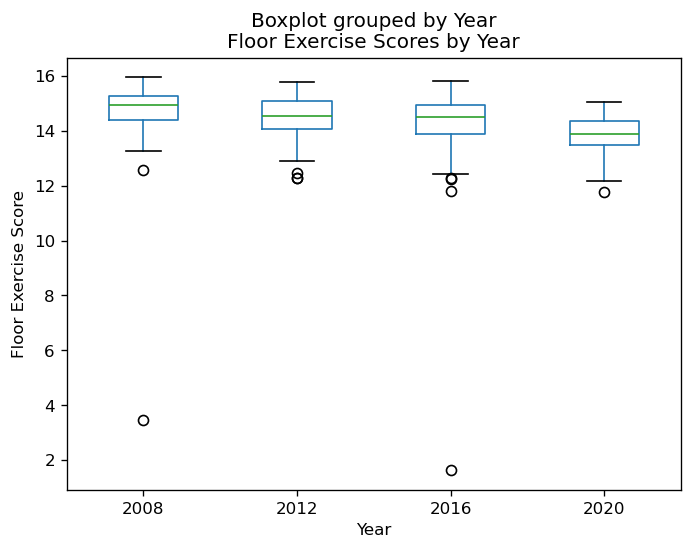

In [ ]:
df_gym_plot = df_gym_events.reset_index()

ax = df_gym_plot.boxplot(
    column="Floor Exercise",
    by="Year",
    grid=False
)

ax.set_title("Floor Exercise Scores by Year")
ax.set_xlabel("Year")
ax.set_ylabel("Floor Exercise Score")

12\. Standardize the scores for each of the six events by subtracting the mean for the event and dividing by its standard deviation *within each year*. Note: you can do this for all six events at once. You should NOT write a for loop or create a separate line of code for each event.


In [ ]:
year_means = (
    df_gym_events
    .groupby(level="Year")
    .transform("mean")
)

year_standard_deviations = (
    df_gym_events
    .groupby(level="Year")
    .transform("std")
)

df_gym_standardized_by_year = (
    (df_gym_events - year_means)
    / year_standard_deviations
)

df_gym_standardized_by_year

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar     Rings  Pommelled Horse
Round         Year Gymnast                                                                                                 
Qualification 2012 Danell Leyva             0.753096     0.027915       1.002995        1.708332  0.269011         1.232874
                   David Belyavsky          0.753096     1.451057       0.953577        0.569503 -0.128045         1.271729
                   Fabian HambÃ¼chen        0.794185     0.620298       0.953577        1.442985  0.550683         0.357497
                   John Orozco              0.835273     0.561594      -0.195024        1.025035  1.059729         1.118595
                   Kristian Thomas          1.084294     1.273164      -0.057251        1.138917  0.211319         0.395209
...                                              ...          ...            ...             ...       ...              ...
Final         2008 Daniel Keatings          0.098864    -0.076907      -0.896615       -0.385333 -1.098537         1.745577
                   Thomas Bouhail           0.365547     0.015192      -0.896615       -0.100954 -1.550593        -1.020884
                   José Luis Fuentes       -0.415455    -1.089993       0.063005       -0.470647 -1.227696        -0.720182
                   Dzmitry Savitski        -0.758335     0.107290      -2.208096       -5.077583  0.580528        -0.599901
                   Chen Yibing                   NaN     0.107290      -0.224881       -1.807227  2.324171        -0.599901

[351 rows x 6 columns]

13\. If we standardize within each year, which athletes (and rounds and year) had the highest total standardized values? Basically repeat part 9 but with standardization within each year.

In [ ]:
df_gym_standardized_by_year["Standardized Total"] = (
    df_gym_standardized_by_year[df_gym_events.columns]
    .sum(axis=1, min_count=6)
)

standardized_by_year_ranked = (
    df_gym_standardized_by_year
    .sort_values("Standardized Total", ascending=False)
)

standardized_by_year_ranked.head(10)

Floor Exercise  Horse Vault  Parallel Bars  Horizontal Bar     Rings  Pommelled Horse  Standardized Total
Round         Year Gymnast                                                                                                                   
Final         2016 Oleh Verniaiev         0.520383     1.475149       1.524323        0.534169  2.005141         1.554973            7.614139
              2012 Kohei Uchimura         0.753096     1.390574       0.991015        1.405403  1.512779         1.461432            7.514300
Qualification 2020 Daiki Hashimoto        1.196662     1.341947       1.007048        1.915265  0.443776         1.488590            7.393287
Final         2020 Daiki Hashimoto        1.382156     1.070152       1.007048        1.802342  0.085413         1.898201            7.245313
Qualification 2016 Oleh Verniaiev         0.404528     0.837441       1.600950        0.855432  1.822604         1.589606            7.110561
Final         2016 Kohei Uchimura         0.944993     1.572128       0.943813        1.498922  0.970158         0.890661            6.820674
              2020 Nikita Nagorny         0.824279     1.397615       1.102280        1.162069  1.304708         0.976575            6.767526
Qualification 2020 Nikita Nagorny         1.707119     1.070152       0.688974        1.274992  0.946345         1.078978            6.766560
Final         2020 Xiao Ruoteng           1.196662     1.070152       1.069901        0.823300  1.161578         1.421004            6.742597
              2008 Yang Wei               0.403645     1.304573       1.246537        0.240300  2.291882         1.234383            6.721320